# Edgar demo: symbolic discovery on a toy dataset

This notebook walks through a minimal end-to-end workflow with `Edgar`.
We generate a synthetic dataset with a known symbolic form, define simple
seed programs/parameter estimators, preview the prompts/diagnostics, and
show how to launch the engine and inspect the resulting census snapshots.

> **Note:** Running the full engine still requires valid Google GenAI API
> credentials (\`GOOGLE_API_KEY\`). The cell that actually executes the
> agent is wrapped in a try/except so the rest of the demo can be explored
> even without credentials.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import inspect

from entities import Program
from hypothesis_engine import Edgar, load_program_snapshots
import utils, tuning_curves_project


gpu
[CudaDevice(id=0)]


In [11]:
rng = np.random.default_rng(0)
theta = np.linspace(0, 2 * np.pi, 200)

def ground_truth(theta, amplitude1=1.0, amplitude2=0.5, bias=0.3, freq=2.0, phase=0.0):
    return bias + amplitude1 * np.cos(freq * theta - phase) + amplitude2 * np.cos(freq * (theta -phase)**2)

n_units = 50
X = np.tile(theta, (n_units, 1))
signals = []
for _ in range(n_units):
    amp1 = abs(0.9 + 0.25 * rng.standard_normal())
    amp2 = abs(0.5 + 0.1 * rng.standard_normal())
    bias = 0.2 * rng.random()
    freq = 1.0 + rng.integers(0, 4)
    phase = rng.uniform(0, np.pi)
    clean = ground_truth(theta, amplitude1=amp1, amplitude2=amp2, bias=bias, freq=freq, phase=phase)
    noisy = clean + 0.1 * rng.standard_normal(theta.shape)
    signals.append(noisy)
Y = np.asarray(signals)
print(X.shape, Y.shape)


(50, 200) (50, 200)


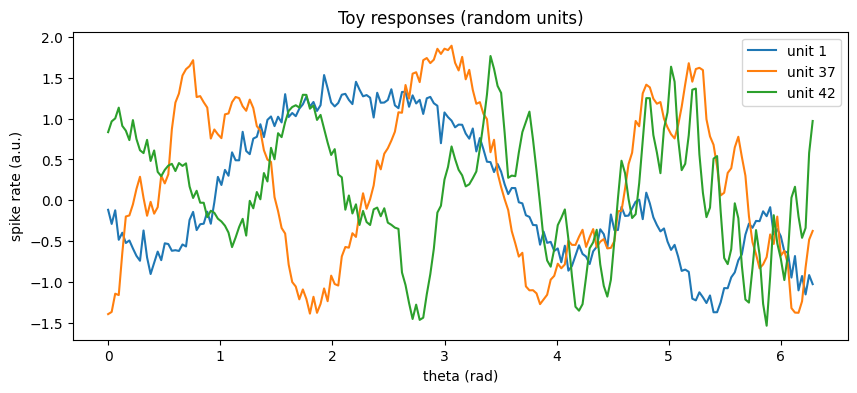

In [32]:
plt.figure(figsize=(10, 4))
random_units = rng.choice(Y.shape[0], size=3, replace=False)  # Select 3 random units
for unit in random_units:
    plt.plot(theta, Y[unit], label=f'unit {unit}')
plt.title('Toy responses (random units)')
plt.xlabel('theta (rad)')
plt.ylabel('spike rate (a.u.)')
plt.legend()
plt.show()


In [28]:
def seed_model_cosine_numpy(theta, A=1.0, B=0.2, phase=0.0):
    theta = np.asarray(theta)
    return B + A * np.cos(theta - phase)

def seed_model_cosine_jax(theta, A=1.0, B=0.2, phase=0.0):
    theta = jnp.asarray(theta)
    return B + A * jnp.cos(theta - phase)

def seed_model_double_cosine_numpy(theta, A1=1.0, A2=0.5, B=0.2, phase=0.0):
    theta = np.asarray(theta)
    return B + A1 * np.cos(theta - phase) + A2 * np.cos(2 * (theta - phase))

def seed_model_double_cosine_jax(theta, A1=1.0, A2=0.5, B=0.2, phase=0.0):
    theta = jnp.asarray(theta)
    return B + A1 * jnp.cos(theta - phase) + A2 * jnp.cos(2 * (theta - phase))

def parameter_estimator_cosine(X, Y):
    """
    X: (n_samples, ), Y: (n_samples, )
    """
    B = np.percentile(Y, 5)
    A = np.max(Y) - B
    # estimate phase by finding theta that gives max response
    theta_max = X[np.argmax(Y)]
    phase = theta_max
    return np.array([A, B, phase])

def parameter_estimator_double_cosine(X, Y):
    """
    X: (n_samples, ), Y: (n_samples, )
    """
    B = np.percentile(Y, 5)
    Y_offset = Y - B
    # estimate phase by finding theta that gives max response
    theta_max = X[np.argmax(Y_offset)]
    phase = theta_max
    # estimate A1 and A2 using Fourier coefficients
    A1 = (2 / len(X)) * np.sum(Y_offset * np.cos(X - phase))
    A2 = (2 / len(X)) * np.sum(Y_offset * np.cos(2 * (X - phase)))
    return np.array([A1, A2, B, phase])
    

In [33]:
agent = Edgar(
    n_generations=1,
    n_islands=1,
    batch_size=1,
    use_image_feedback=False,
    time_limit=0.1,
    seed_functions_numpy=[seed_model_cosine_numpy,
                           seed_model_double_cosine_numpy],
    seed_functions_jax=[seed_model_cosine_jax,
                        seed_model_double_cosine_jax],
    seed_parameter_estimators=[parameter_estimator_cosine,
                              parameter_estimator_double_cosine],
    tiny_lm_name='gemini-1.5-flash',
    little_lm_name='gemini-2.0-flash',
    large_lm_name='gemini-2.5-flash',
)
try:
    agent.run(jnp.asarray(X), jnp.asarray(Y))
    print('Run finished, snapshots:', len(agent.snapshots_))
except Exception as exc:
    print('Edgar run skipped (likely missing API key):', exc)


Edgar run skipped (likely missing API key): asyncio.run() cannot be called from a running event loop


/tmp/ipykernel_2150322/2995176010.py:21: RuntimeWarning: coroutine 'Edgar.run_async' was never awaited
  print('Edgar run skipped (likely missing API key):', exc)


In [ ]:
if agent.snapshots_:
    agent.plot_progress(metric='train')
    plt.show()
    agent.plot_lineage()
    plt.show()
else:
    print('No snapshots are available yet. Once a run completes you can use agent.plot_progress() and agent.plot_lineage().')


In [ ]:
if agent.snapshots_:
    for snap in agent.snapshots_[:3]:
        display(snap.to_dict())
else:
    print('Snapshots can also be reloaded later:')